In [1]:
import torch
from PIL import Image
from torchvision import models
from torchvision import transforms

In [2]:
img=Image.open(r'C:\Users\sshak\Downloads\cat.jpg')

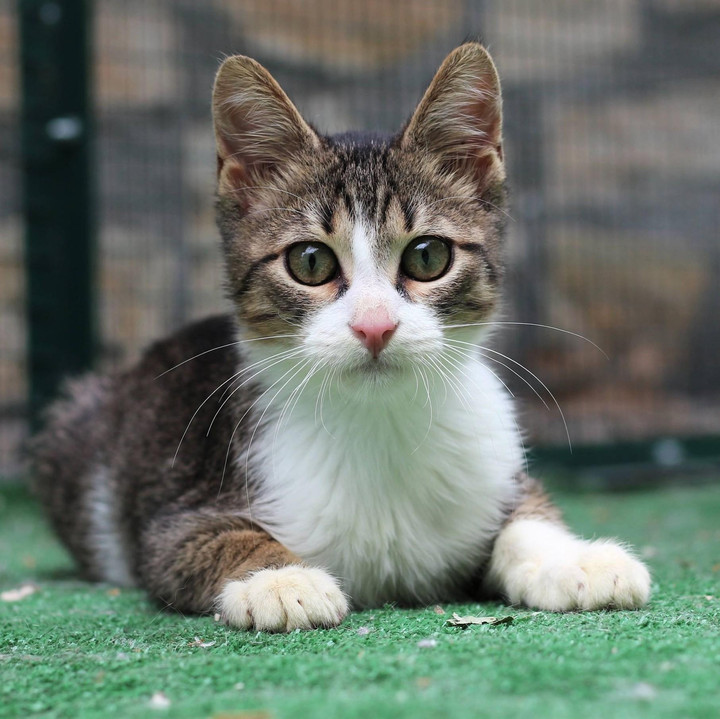

In [3]:
img

In [ ]:
preprocess=transforms.Compose

In [4]:
resnet=models.resnet18(pretrained=True)
resnet.eval()

c:\Users\sshak\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sshak\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sshak/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:31<00:00, 1.51MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
class GradCAM:
    def __init__(self,model,target_layer) -> None:
        self.model=model
        self.activation_maps=None
        self.gradient_maps=None

    def generate_cam(Self,input_tensor):
        output=self.model(input_tensor)
        class_idx=torch.argmax(output,dim=1)
        print(class_idx)
grad_cam=GradCAM(resnet_model,'layer4')



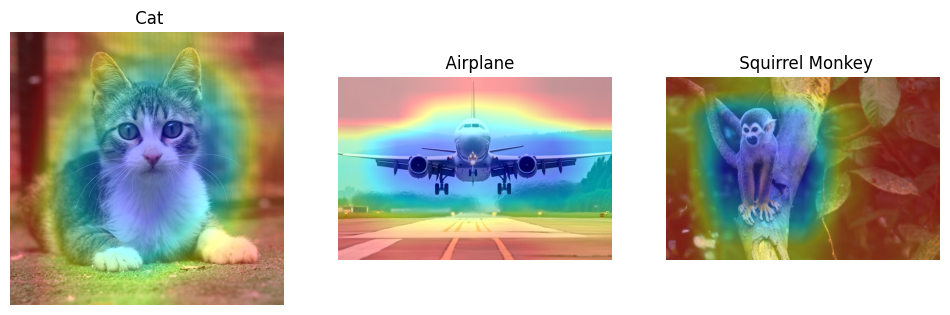

In [22]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load pre-trained ResNet50 model
model = models.resnet50(pretrained=True)
model.eval()
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_image(img_path):
    img = Image.open(img_path)
    img_tensor = preprocess(img).unsqueeze(0)  # Add batch dimension
    return img_tensor, img

cat_img_tensor, cat_img = load_image('cat.jpg')
airplane_img_tensor, airplane_img = load_image('airplane.jpg')
monkey_img_tensor, monkey_img = load_image('squirrel_monkey.jpg')



class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register the hooks
        self.hooks()

    def hooks(self):
        # Register forward hook to get the activations
        def forward_hook(module, input, output):
            self.activations = output

        # Register backward hook to get the gradients
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]

        # Attach hooks to the target layer
        target_module = dict(self.model.named_modules())[self.target_layer]
        target_module.register_forward_hook(forward_hook)
        target_module.register_backward_hook(backward_hook)

    def forward(self, img_tensor):
        # Forward pass through the model
        return self.model(img_tensor)

    def backward(self, output, class_idx):
        # Backward pass to get the gradient with respect to the predicted class
        self.model.zero_grad()
        class_output = output[:, class_idx]
        class_output.backward(retain_graph=True)

    def generate_cam(self):
        # Compute the Grad-CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])  # Global average pooling

        # Multiply the gradients with activations
        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :] *= pooled_gradients[i]

        # Compute the heatmap
        heatmap = torch.mean(self.activations, dim=1).squeeze().detach().cpu().numpy()
        heatmap = np.maximum(heatmap, 0)  # ReLU
        heatmap /= np.max(heatmap)  # Normalize

        return heatmap
# Load pre-trained model
model = models.resnet50(pretrained=True)
model.eval()

# Initialize Grad-CAM for the 'layer4' of ResNet50
grad_cam = GradCAM(model, target_layer='layer4')

# Forward pass for each image
cat_output = grad_cam.forward(cat_img_tensor)
cat_class_idx = torch.argmax(cat_output).item()

# Backward pass to get the gradients for the class
grad_cam.backward(cat_output, cat_class_idx)
cat_heatmap = grad_cam.generate_cam()

# Forward pass for the airplane
airplane_output = grad_cam.forward(airplane_img_tensor)
airplane_class_idx = torch.argmax(airplane_output).item()
grad_cam.backward(airplane_output, airplane_class_idx)
airplane_heatmap = grad_cam.generate_cam()

# Forward pass for the monkey
monkey_output = grad_cam.forward(monkey_img_tensor)
monkey_class_idx = torch.argmax(monkey_output).item()
grad_cam.backward(monkey_output, monkey_class_idx)
monkey_heatmap = grad_cam.generate_cam()

# Function to apply heatmap
def apply_heatmap(img, heatmap):
    heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = cv2.addWeighted(np.array(img), 0.7, heatmap, 0.4, 0)
    return superimposed_img

# Apply heatmaps and visualize
cat_cam = apply_heatmap(cat_img, cat_heatmap)
airplane_cam = apply_heatmap(airplane_img, airplane_heatmap)
monkey_cam = apply_heatmap(monkey_img, monkey_heatmap)

# Display images with heatmaps
plt.figure(figsize=(12, 4))
plt.subplot(131)
plt.imshow(cat_cam)
plt.title(" Cat")
plt.axis('off') 
plt.subplot(133)
plt.imshow(monkey_cam)
plt.title(" Squirrel Monkey")
plt.axis('off') 
plt.subplot(132)
plt.imshow(airplane_cam)
plt.title("  Airplane")
plt.axis('off') 


plt.show()


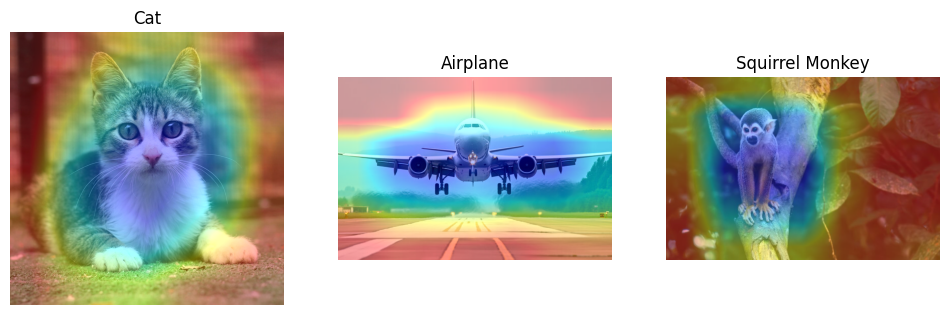

In [24]:
import matplotlib.pyplot as plt

# Save each heatmap image
plt.imsave('cat_cam.png', cat_cam)
plt.imsave('airplane_cam.png', airplane_cam)
plt.imsave('monkey_cam.png', monkey_cam)

# Display images with heatmaps
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.imshow(cat_cam)
plt.title("Cat")
plt.axis('off') 

plt.subplot(132)
plt.imshow(airplane_cam)
plt.title("Airplane")
plt.axis('off') 

plt.subplot(133)
plt.imshow(monkey_cam)
plt.title("Squirrel Monkey")
plt.axis('off') 

plt.show()


c:\Users\sshak\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\nn\modules\module.py:1373: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


RuntimeError: Mismatch in shape: grad_output[0] has a shape of torch.Size([1, 1000]) and output[0] has a shape of torch.Size([1, 2048, 7, 7]).